# Task 1.1 Feynman Equation Preprocessing Pipeline

This notebook covers my implementation of Task 1.1 for the SYMBA project under ML4SCI GSoC 2026. The task itself is about taking the 100 AI Feynman physics equations and converting them into machine-readable formats that the training pipeline can consume directly.

The notebook produces two output files:

| Output file | Used by | Purpose |
|---|---|---|
| `task1_1_tokenized_postfix.json` | `REAL_LABEL` | Postfix token sequences, vocabulary, encoded indices, and the 67/18/15 train/val/test split |
| `isha_data_clouds.json` | `REAL_CLOUD` | 200 sampled (input, output) data points per equation for the SineKAN encoder |

### Design decisions worth noting

- **SymPy-based parsing:** Rather than writing a custom parser, I walk the SymPy expression tree (AST) recursively. This handles operator precedence and nested function composition correctly without any special cases.
- **Postfix (RPN) notation:** The autoregressive decoder generates tokens left-to-right. With postfix ordering, the stack depth at any point during generation is deterministically computable from the tokens already emitted this is what makes grammar-constrained beam search tractable.
- **Range-aware point sampling:** Variable ranges are taken directly from the Feynman dataset metadata, so the sampled point clouds stay within physically valid domains.
- **Unified vocabulary:** Special tokens are kept consistent with the synthetic pretraining vocabulary so that Phase 2 fine-tuning does not require any vocabulary remapping.

In [1]:
!pip install sympy pandas matplotlib scikit-learn --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import sympy
from sympy import symbols, asin, acos, atan, lambdify
from sympy.parsing.sympy_parser import parse_expr, standard_transformations

from collections import Counter
import matplotlib.pyplot as plt
import json, warnings, random
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print("All imports OK")

All imports OK


## Configuration

The only path that needs updating is `CSV_PATH` — point it to your local copy of `FeynmanEquations.csv`. The output paths (`OUT_LABELS` and `OUT_CLOUDS`) are already set to match the `REAL_LABEL` and `REAL_CLOUD` constants in `src/config.py`, so those can stay as-is.

In [3]:
CSV_PATH   = r'../data/FeynmanEquations.csv'
OUT_LABELS = r'../data/task1_1_tokenized_postfix.json'
OUT_CLOUDS = r'../data/clouds/isha_data_clouds.json'

N_CLOUD_PTS = 200
MAX_D       = 10
RANDOM_SEED = 42

print(f"Cloud pts : {N_CLOUD_PTS}  |  MAX_D : {MAX_D}")

Cloud pts : 200  |  MAX_D : 10


In [4]:
data = pd.read_csv(CSV_PATH)
data = data.dropna(subset=['Formula']).reset_index(drop=True)
print(f'Total equations in the dataset: {len(data)}')
data[['Filename', 'Formula', '# variables']].head(6)

Total equations in the dataset: 97


,Filename,Formula,# variables
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),1.0
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2.0
2,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3.0
3,I.8.14,sqrt((x2-x1)**2+(y2-y1)**2),4.0
4,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),9.0
5,I.10.7,m_0/sqrt(1-v**2/c**2),3.0


## Recursive Tree Walker

Feynman equations often involve deeply nested expressions , something like `exp(-((theta-theta1)/sigma)**2/2)` has four levels of nesting with operator precedence interacting with function application in ways that are genuinely non-trivial to handle with a regex or string-split approach.

The cleaner solution is to let SymPy parse the formula into a canonical expression tree and then walk that tree recursively, emitting one token per node in post-order. This is deterministic and structure-preserving by construction.

 The two plots below give a sense of the dataset: how many variables the equations involve, and how long the raw formula strings are.

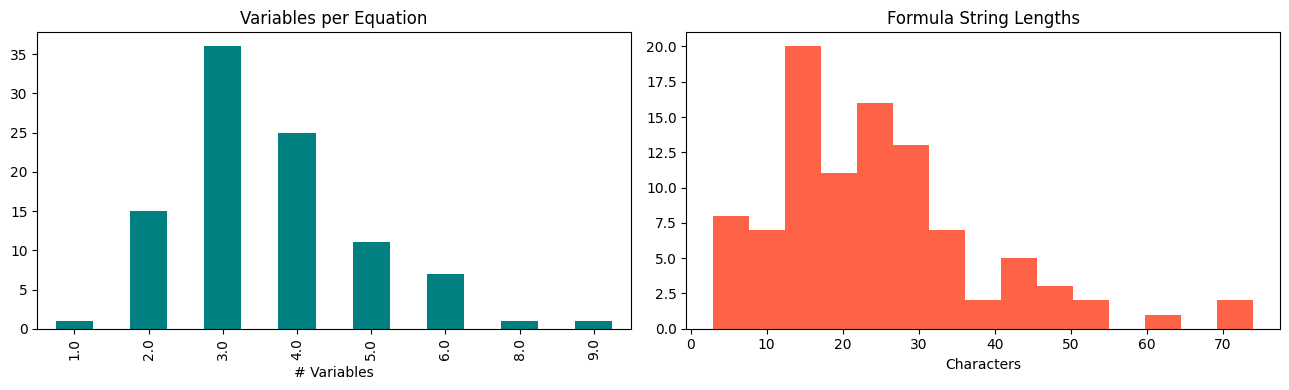

Shortest formula: 3 chars
Longest formula : 74 chars


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
data['# variables'].value_counts().sort_index().plot.bar(
    ax=ax[0], color='teal', title='Variables per Equation')
ax[0].set_xlabel('# Variables')

data['formula_str_len'] = data['Formula'].str.len()
ax[1].hist(data['formula_str_len'], bins=15, color='tomato')
ax[1].set(title='Formula String Lengths', xlabel='Characters')
plt.tight_layout(); plt.show()

print(f"Shortest formula: {data['formula_str_len'].min()} chars")
print(f"Longest formula : {data['formula_str_len'].max()} chars")

Most equations involve 3 variables. Formula length in raw string form ranges from 3 to about 74 characters, with the majority falling between 10 and 40. The distribution is right-skewed , a few equations like `I.9.18` involve 9 variables and correspondingly longer expressions. This spread in complexity is worth keeping in mind when setting `MAX_LEN` for padding later.

## Variable Extraction and Sampling Ranges

The Feynman CSV includes predefined ranges for each variable (`v{i}_low`, `v{i}_high`), which I extract along with the variable names. These ranges are important during point cloud generation, since I sample values uniformly within them.

Doing this ensures that the generated data points stay **physically meaningful** and **numerically stable**, instead of running into issues like singularities or overflow.

In [6]:
var_name_cols = [f'v{i}_name' for i in range(1, 11)]
data['variables'] = data[var_name_cols].apply(
    lambda r: r.dropna().astype(str).tolist(), axis=1
)

def get_ranges(row):
    ranges = {}
    for i in range(1, 11):
        name = row.get(f'v{i}_name')
        if pd.isna(name):
            continue
        low  = row.get(f'v{i}_low',  1.0)
        high = row.get(f'v{i}_high', 5.0)
        low  = float(low)  if not pd.isna(low)  else 1.0
        high = float(high) if not pd.isna(high) else 5.0
        if low >= high:
            high = low + 1.0
        ranges[str(name)] = (low, high)
    return ranges

data['var_ranges'] = data.apply(get_ranges, axis=1)

print("Sample variable ranges:")
for _, r in data.head(5).iterrows():
    print(f"  {r['Filename']}: {r['var_ranges']}")

Sample variable ranges:
  I.6.2a: {'theta': (1.0, 3.0)}
  I.6.2: {'sigma': (1.0, 3.0), 'theta': (1.0, 3.0)}
  I.6.2b: {'sigma': (1.0, 3.0), 'theta': (1.0, 3.0), 'theta1': (1.0, 3.0)}
  I.8.14: {'x1': (1.0, 5.0), 'x2': (1.0, 5.0), 'y1': (1.0, 5.0), 'y2': (1.0, 5.0)}
  I.9.18: {'m1': (1.0, 2.0), 'm2': (1.0, 2.0), 'G': (1.0, 2.0), 'x1': (3.0, 4.0), 'x2': (1.0, 2.0), 'y1': (3.0, 4.0), 'y2': (1.0, 2.0), 'z1': (3.0, 4.0), 'z2': (1.0, 2.0)}


## Postfix (RPN) Tokenisation

The choice of postfix notation deserves a bit more explanation. In prefix notation, the decoder emits an operator *before* knowing how many arguments it will generate, which makes stack-depth validation during beam search awkward. With postfix, the operator always comes *after* its operands so by the time the model predicts an operator token, the stack already holds exactly the right number of values. The stack depth is fully determined by any left-to-right prefix of the sequence, and this property is directly exploited in the grammar-constrained beam search implemented in `pipeline/beam_search.py`.

The implementation change from prefix to postfix is minimal: instead of emitting the operator token first and then recursing into children, we recurse into all children first and append the operator token last.

In [7]:
OP_MAP = {
    sympy.Add:  'OP_add',
    sympy.Mul:  'OP_mul',
    sympy.Pow:  'OP_pow',
    sympy.exp:  'FUNC_exp',
    sympy.log:  'FUNC_log',
    sympy.sin:  'FUNC_sin',
    sympy.cos:  'FUNC_cos',
    sympy.tan:  'FUNC_tan',
    sympy.sqrt: 'FUNC_sqrt',
    sympy.Abs:  'FUNC_abs',
    sympy.asin: 'FUNC_arcsin',
    sympy.acos: 'FUNC_arccos',
    sympy.atan: 'FUNC_arctan',
    sympy.tanh: 'FUNC_tanh',
}


def tree_to_postfix(expr, depth=0):
    if depth > 60:
        return ['<UNK>']
    if expr == sympy.pi:   return ['CONST_pi']
    if expr == sympy.E:    return ['CONST_E']
    if expr.is_Symbol:     return [f'VAR_{str(expr)}']
    if expr.is_Number:     return ['<C>']
    if type(expr) in OP_MAP:
        result = []
        for child in expr.args:
            result.extend(tree_to_postfix(child, depth + 1))
        result.append(OP_MAP[type(expr)])
        return result
    return ['<UNK>']


def tokenize_row(row):
    try:
        local_syms = {v: symbols(v) for v in row['variables']}
        local_syms.update({'arcsin': asin, 'arccos': acos, 'arctan': atan})
        expr = parse_expr(row['Formula'],
                          local_dict=local_syms,
                          transformations=standard_transformations)
        return ['<BOS>'] + tree_to_postfix(expr) + ['<EOS>']
    except Exception as e:
        print(f"  Skipped {row['Filename']}: {e}")
        return None

Before running the tokeniser on the full dataset, it is worth verifying the conversion on a simple expression. For `x + 4`, the expected postfix output is `['VAR_x', '<C>', 'OP_add']` which is operands first, operator last. The cell below confirms this and also shows what the equivalent prefix sequence would look like for comparison.

In [8]:
test_expr = parse_expr('x + 4',
                       local_dict={'x': symbols('x')},
                       transformations=standard_transformations)
postfix_result = tree_to_postfix(test_expr)
print(f"x + 4  â†’  postfix: {postfix_result}")
print(f"         (prefix would be: ['OP_add', 'VAR_x', '<C>'])")

x + 4  â†’  postfix: ['<C>', 'VAR_x', 'OP_add']
         (prefix would be: ['OP_add', 'VAR_x', '<C>'])


In [9]:
data['tokens'] = data.apply(tokenize_row, axis=1)
data['token_length'] = data['tokens'].apply(lambda x: len(x) if x else None)
clean = data.dropna(subset=['tokens']).copy()

print(f'Tokenised {len(clean)}/{len(data)} equations\n')
for _, row in clean.head(8).iterrows():
    print(f"{row['Filename']}: {row['Formula']}")
    print(f"  â†’ {' '.join(row['tokens'])}\n")

Tokenised 97/97 equations

I.6.2a: exp(-theta**2/2)/sqrt(2*pi)
  â†’ <BOS> <C> <C> <C> OP_pow CONST_pi <C> OP_pow <C> VAR_theta <C> OP_pow OP_mul FUNC_exp OP_mul <EOS>

I.6.2: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
  â†’ <BOS> <C> <C> <C> OP_pow CONST_pi <C> OP_pow VAR_sigma <C> OP_pow <C> VAR_sigma <C> OP_pow VAR_theta <C> OP_pow OP_mul FUNC_exp OP_mul <EOS>

I.6.2b: exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)
  â†’ <BOS> <C> <C> <C> OP_pow CONST_pi <C> OP_pow VAR_sigma <C> OP_pow <C> VAR_sigma <C> OP_pow VAR_theta <C> VAR_theta1 OP_mul OP_add <C> OP_pow OP_mul FUNC_exp OP_mul <EOS>

I.8.14: sqrt((x2-x1)**2+(y2-y1)**2)
  â†’ <BOS> VAR_x2 <C> VAR_x1 OP_mul OP_add <C> OP_pow VAR_y2 <C> VAR_y1 OP_mul OP_add <C> OP_pow OP_add <C> OP_pow <EOS>

I.9.18: G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)
  â†’ <BOS> VAR_G VAR_m1 VAR_m2 VAR_x2 <C> VAR_x1 OP_mul OP_add <C> OP_pow VAR_y2 <C> VAR_y1 OP_mul OP_add <C> OP_pow VAR_z2 <C> VAR_z1 OP_mul OP_add <C> OP_pow OP_add <C> OP_pow OP_mu

97/97 equations tokenised successfully. One thing to note: SymPy normalises expressions before we walk the tree. For example, `x - y` is internally represented as `Add(x, Mul(-1, y))`, which produces the postfix sequence `VAR_x <C> VAR_y OP_mul OP_add` rather than a subtraction token. Similarly, division becomes multiplication by a reciprocal. This canonical form is consistent and unambiguous, but it does mean the vocabulary has no explicit subtraction or division operator and the negation and reciprocals are represented through constants and `OP_mul`/`OP_pow`.

## Vocabulary Construction

The vocabulary is built from all tokens that appear across the 97 successfully tokenised equations. Special tokens (`<PAD>`, `<BOS>`, `<EOS>`, `<C>`, `<UNK>`) are assigned the lowest indices (0–4) to keep masking consistent. Remaining tokens are sorted by frequency so the most common operators end up with small indices, which gives slightly better embedding initialisation in practice.

The output below shows the final vocab size and the breakdown by token type.

In [10]:
all_tokens    = [tok for seq in clean['tokens'] for tok in seq]
vocab_counter = Counter(all_tokens)

SPECIAL   = ['<PAD>', '<BOS>', '<EOS>', '<C>', '<UNK>']
vocab     = SPECIAL + sorted(
    [t for t in vocab_counter if t not in SPECIAL],
    key=lambda t: -vocab_counter[t]
)
token2idx = {t: i for i, t in enumerate(vocab)}
idx2token = {i: t for t, i in token2idx.items()}

print(f'Vocab size : {len(vocab)}')
print(f'Operators  : {[t for t in vocab if t.startswith("OP_")]}')
print(f'Functions  : {[t for t in vocab if t.startswith("FUNC_")]}')
print(f'Constants  : {[t for t in vocab if t.startswith("CONST_")]}')
print(f'Variables  : {len([t for t in vocab if t.startswith("VAR_")])} unique variable names')

Vocab size : 105
Operators  : ['OP_pow', 'OP_mul', 'OP_add']
Functions  : ['FUNC_cos', 'FUNC_exp', 'FUNC_sin', 'FUNC_log', 'FUNC_tanh']
Constants  : ['CONST_pi']
Variables  : 91 unique variable names


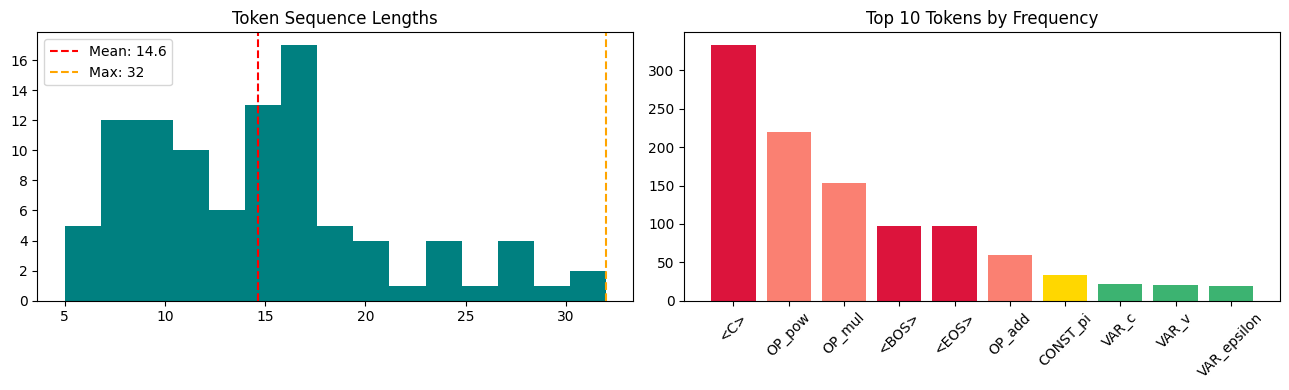

count    97.00
mean     14.64
std       6.21
min       5.00
25%      10.00
50%      14.00
75%      17.00
max      32.00
Name: token_length, dtype: float64


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Token sequence length distribution
l = clean['token_length']
ax[0].hist(l, bins=15, color='teal')
ax[0].axvline(l.mean(), ls='--', c='red',    label=f'Mean: {l.mean():.1f}')
ax[0].axvline(l.max(),  ls='--', c='orange', label=f'Max: {l.max()}')
ax[0].set_title('Token Sequence Lengths')
ax[0].legend()

# Top 10 token frequencies
t_top, c_top = zip(*vocab_counter.most_common(10))
colors = [
    'salmon'        if x.startswith('OP_')    else
    'steelblue'     if x.startswith('FUNC_')  else
    'mediumseagreen' if x.startswith('VAR_')  else
    'gold'          if x.startswith('CONST_') else
    'crimson'
    for x in t_top
]
ax[1].bar(t_top, c_top, color=colors)
ax[1].set_title('Top 10 Tokens by Frequency')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(l.describe().round(2))

## Encoding and Train / Val / Test Splits

All token sequences are padded to a fixed length of `MAX_LEN = max_token_length + 5` using `<PAD>` tokens. The +5 buffer ensures no sequence hits the padding boundary even after SymPy normalisation occasionally produces slightly longer outputs than the raw formula string suggests.

The split is **67 / 18 / 15** (train / val / test). The 15 test equations are held out entirely as in the model never sees them during any phase of training. One thing worth noting: `train.py` rebuilds the unified vocabulary at runtime by combining synthetic and Feynman tokens together, then re-encodes everything. The encoded indices saved here are for standalone use and reference only.

In [12]:
MAX_LEN = int(clean['token_length'].max()) + 5
print(f'Padding all sequences to: {MAX_LEN} tokens')

def encode(token_seq):
    ids = [token2idx.get(t, token2idx['<UNK>']) for t in token_seq]
    ids = ids[:MAX_LEN]
    ids += [token2idx['<PAD>']] * (MAX_LEN - len(ids))
    return ids

clean['encoded'] = clean['tokens'].apply(encode)

train_val, test_data  = train_test_split(clean, test_size=15,  random_state=RANDOM_SEED)
train_data, val_data  = train_test_split(train_val, test_size=18, random_state=RANDOM_SEED)
print(f'Train: {len(train_data)}  |  Val: {len(val_data)}  |  Test: {len(test_data)}')

Padding all sequences to: 37 tokens
Train: 64  |  Val: 18  |  Test: 15


## Point Cloud Generation

The SineKAN encoder does not take the equation directly. Instead, it works on a *point cloud*, which is just a set of input values and output pairs that describe the function numerically.

For each equation, I generate the point cloud as follows:
1. Sample `N_CLOUD_PTS = 200` input vectors uniformly within the given variable ranges  
2. Evaluate the equation using `lambdify` with NumPy for fast, vectorised computation  
3. Filter out any invalid values, such as non-finite outputs or values larger than `1e6`, which usually come from singularities or numerical instability  
4. If fewer than 200 valid samples remain, repeat the valid ones to fill the gap; otherwise, truncate to 200  
5. Combine inputs and outputs into a single array of shape `(200, n_vars + 1)`

During training, `pad_and_normalise` in `dataset.py` handles two things: it pads the feature dimension so that the max dimension is 10 and applies per-column z-score normalisation.

In [13]:
def generate_cloud(row, n_pts=N_CLOUD_PTS):
    variables  = row['variables']
    var_ranges = row['var_ranges']
    n_vars     = len(variables)
    if n_vars == 0:
        return None

    try:
        local_syms = {v: sympy.Symbol(v) for v in variables}
        local_syms.update({'arcsin': asin, 'arccos': acos, 'arctan': atan})
        expr = parse_expr(row['Formula'],
                          local_dict=local_syms,
                          transformations=standard_transformations)

        sym_vars = [sympy.Symbol(v) for v in variables]
        f = lambdify(sym_vars, expr, modules=['numpy'])

        X = np.zeros((n_pts, n_vars))
        for i, var in enumerate(variables):
            lo, hi = var_ranges.get(var, (1.0, 5.0))
            X[:, i] = np.random.uniform(lo, hi, n_pts)

        args = [X[:, i] for i in range(n_vars)]
        y    = f(*args) if n_vars > 1 else f(args[0])
        y    = np.asarray(y, dtype=float).flatten()

        if y.shape[0] == 1:
            y = np.full(n_pts, float(y[0]))

        valid = np.isfinite(y) & (np.abs(y) < 1e6)
        if valid.sum() < 30:
            return None

        X_v, y_v = X[valid], y[valid]

        if X_v.shape[0] < n_pts:
            rep  = (n_pts // X_v.shape[0]) + 1
            X_v  = np.tile(X_v, (rep, 1))[:n_pts]
            y_v  = np.tile(y_v, rep)[:n_pts]

        cloud = np.column_stack([X_v[:n_pts], y_v[:n_pts]])
        return cloud.tolist()

    except Exception:
        return None

In [14]:
clouds = []
failed = []

for _, row in clean.iterrows():
    cld = generate_cloud(row)
    if cld is not None:
        clouds.append({
            'filename': row['Filename'],
            'inputs':   row['variables'],
            'data':     cld
        })
    else:
        failed.append(row['Filename'])

print(f"Clouds generated : {len(clouds)} / {len(clean)}")
if failed:
    print(f"Failed: {failed}")
else:
    print("All equations produced valid clouds.")

Clouds generated : 97 / 97
All equations produced valid clouds.


All 97 out of 97 clouds were generated successfully for this dataset. In general, failures can happen for some equations. This usually comes up when arcsin or arccos get values outside the valid range of [-1, 1], or when denominators get very close to zero and produce too many invalid values to get 200 usable samples.If that happens, it’s handled at the dataset level. The RealDataset class in dataset.py just skips those equations using a simple lookup check when loading the data, so training isn’t affected.

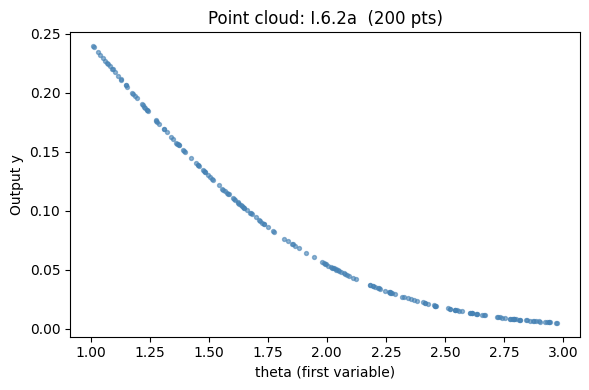

In [ ]:
if clouds:
    sample = np.array(clouds[0]['data'])  
    y_col  = sample[:, -1]
    x_col  = sample[:, 0]
    plt.figure(figsize=(6, 4))
    plt.scatter(x_col, y_col, s=8, alpha=0.6, c='steelblue')
    plt.xlabel(f"{clouds[0]['inputs'][0]} (first variable)")
    plt.ylabel('Output y')
    plt.title(f"Point cloud: {clouds[0]['filename']}  ({len(sample)} pts)")
    plt.tight_layout(); plt.show()

## Saving Outputs

Two JSON files are saved, matching the path constants in `src/config.py`:

- **`task1_1_tokenized_postfix.json`** — vocabulary, train/val/test split records, raw token sequences, and encoded (padded) integer sequences
- **`isha_data_clouds.json`** — point clouds indexed by Feynman filename

These files are saved directly to `data/` -- the same paths `train.py` and `evaluate.py` read from, so the pipeline is ready to run immediately after this notebook completes.

In [16]:
def to_records(split_df):
    return [
        {
            'filename':  row['Filename'],
            'formula':   row['Formula'],
            'variables': row['variables'],
            'tokens':    row['tokens'],
            'encoded':   row['encoded'],
            'token_len': int(row['token_length']),
        }
        for _, row in split_df.iterrows()
    ]

output = {
    'metadata': {
        'dataset':           'AI Feynman (Udrescu & Tegmark, 2019)',
        'notation':          'postfix (RPN)',
        'parser':            'SymPy AST recursive tree walker â€” postfix order',
        'split_ratios':      [0.67, 0.18, 0.15],
        'max_len':           MAX_LEN,
        'vocab_size':        len(vocab),
        'total_equations':   len(clean),
    },
    'vocab':     vocab,
    'token2idx': token2idx,
    'idx2token': {str(i): t for t, i in token2idx.items()},
    'train':     to_records(train_data),
    'val':       to_records(val_data),
    'test':      to_records(test_data),
}

with open(OUT_LABELS, 'w') as f:
    json.dump(output, f, indent=2)

print(f"Saved {OUT_LABELS}")
print(f"  Train: {len(output['train'])}  |  Val: {len(output['val'])}  |  Test: {len(output['test'])}")
print(f"  Vocab size: {output['metadata']['vocab_size']}  |  Max seq len: {output['metadata']['max_len']}")

Saved data/preprocessing_output/task1_1_tokenized_postfix.json
  Train: 64  |  Val: 18  |  Test: 15
  Vocab size: 105  |  Max seq len: 37


In [17]:
with open(OUT_CLOUDS, 'w') as f:
    json.dump(clouds, f, indent=2)

print(f"Saved {OUT_CLOUDS}  ({len(clouds)} equations)")
print(f"Each cloud: {N_CLOUD_PTS} points Ã— (n_vars + 1) columns")

Saved data/preprocessing_output/isha_data_clouds.json  (97 equations)
Each cloud: 200 points Ã— (n_vars + 1) columns


## Summary

The pipeline starts by parsing each equation using SymPy’s parse_expr, which builds the expression tree and correctly handles functions like arcsin, arccos, arctan, and nested expressions. Tokenisation is done using a recursive post-order traversal, where each operator is added after its children, giving a postfix representation.

The vocabulary includes special tokens along with operators, functions, and variables, resulting in 105 tokens in total for the Feynman dataset. The data is split into 67 training, 18 validation, and 15 test equations using a fixed random seed. For each equation, I generate 200 sampled input-output pairs within the given variable ranges, filtering out invalid values and repeating valid ones if needed.

The final outputs are two files, task1_1_tokenized_postfix.json and isha_data_clouds.json, which can be used directly in train.py through the REAL_LABEL and REAL_CLOUD configuration. The test split is kept completely separate and is not used during training or validation.